In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "../data/analytical/base_analitica_v1.parquet"
)

df.head()

,id_municipio,Municipio,UF,Capital,taxa_alfabetizacao_2023,percentual_participacao_2023,meta_alfabetizacao_2024,taxa_alfabetizacao_2024,gap_meta_2024,target_atingiu_meta_2024
0,2406908,Lucrécia,RN,Falso,4.4,82.14,7.94,42.86,3.54,1
1,1718501,Recursolândia,TO,Falso,4.6,95.65,8.25,50.29,3.65,1
2,2919900,Macururé,BA,Falso,4.7,87.76,8.39,12.50,3.69,1
3,1716307,Pau D'Arco,TO,Falso,6.5,82.69,11.05,37.96,4.55,1
4,2205581,Lagoa do Piauí,PI,Falso,7.2,91.23,11.95,44.87,4.75,1


In [2]:
df["id_municipio"].nunique()

5232

In [3]:
len(df)

5232

In [4]:
df["id_municipio"].duplicated().sum()

np.int64(0)

In [5]:
(
    df.isna().mean() * 100
).sort_values(
    ascending=False
)

id_municipio                    0.0
Municipio                       0.0
UF                              0.0
Capital                         0.0
taxa_alfabetizacao_2023         0.0
percentual_participacao_2023    0.0
meta_alfabetizacao_2024         0.0
taxa_alfabetizacao_2024         0.0
gap_meta_2024                   0.0
target_atingiu_meta_2024        0.0
dtype: float64

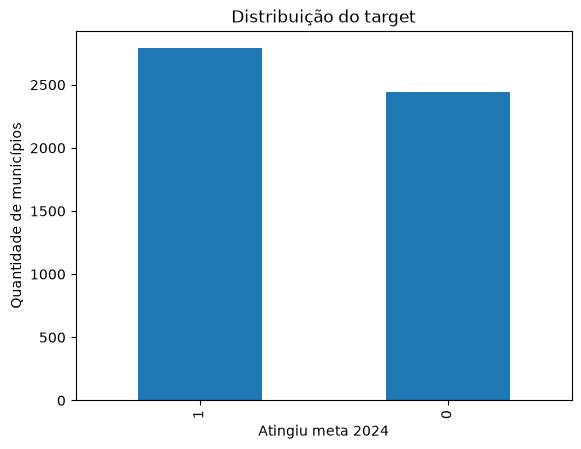

In [6]:
df["target_atingiu_meta_2024"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Atingiu meta 2024")
plt.ylabel("Quantidade de municípios")
plt.title("Distribuição do target")

plt.show()

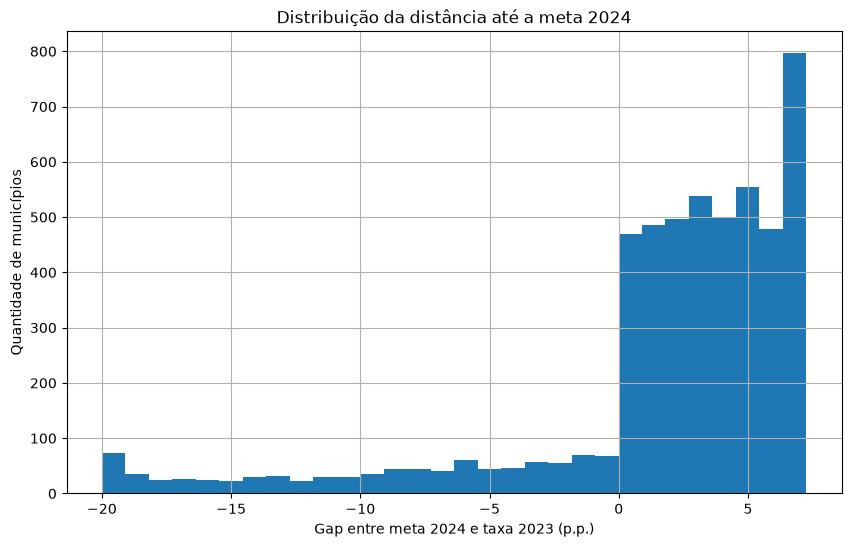

In [7]:
df["gap_meta_2024"].hist(
    bins=30,
    figsize=(10, 6)
)

plt.xlabel("Gap entre meta 2024 e taxa 2023 (p.p.)")
plt.ylabel("Quantidade de municípios")
plt.title("Distribuição da distância até a meta 2024")

plt.show()

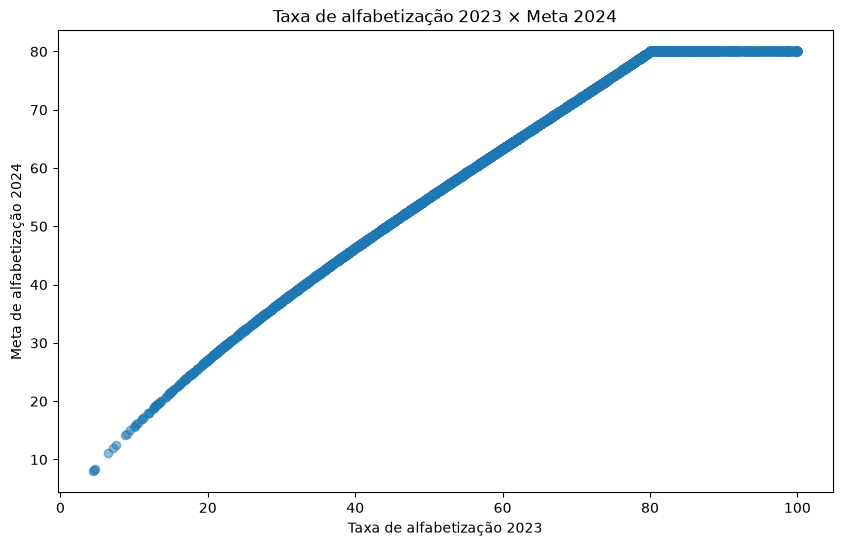

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["taxa_alfabetizacao_2023"],
    df["meta_alfabetizacao_2024"],
    alpha=0.5
)

plt.xlabel("Taxa de alfabetização 2023")
plt.ylabel("Meta de alfabetização 2024")
plt.title("Taxa de alfabetização 2023 × Meta 2024")

plt.show()

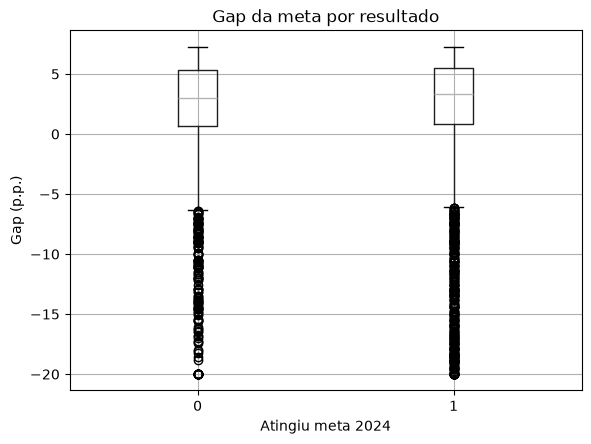

In [9]:
df.boxplot(
    column="gap_meta_2024",
    by="target_atingiu_meta_2024"
)

plt.suptitle("")
plt.title("Gap da meta por resultado")
plt.xlabel("Atingiu meta 2024")
plt.ylabel("Gap (p.p.)")

plt.show()

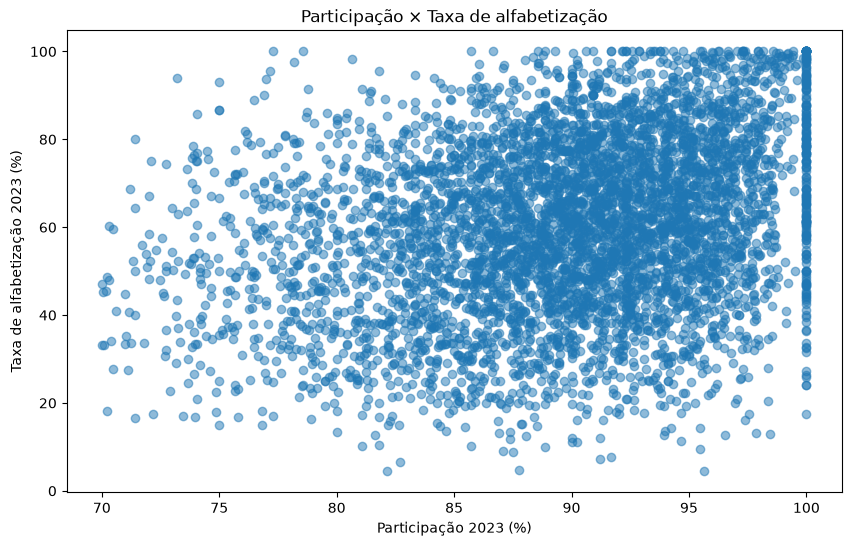

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["percentual_participacao_2023"],
    df["taxa_alfabetizacao_2023"],
    alpha=0.5
)

plt.xlabel("Participação 2023 (%)")
plt.ylabel("Taxa de alfabetização 2023 (%)")
plt.title("Participação × Taxa de alfabetização")

plt.show()

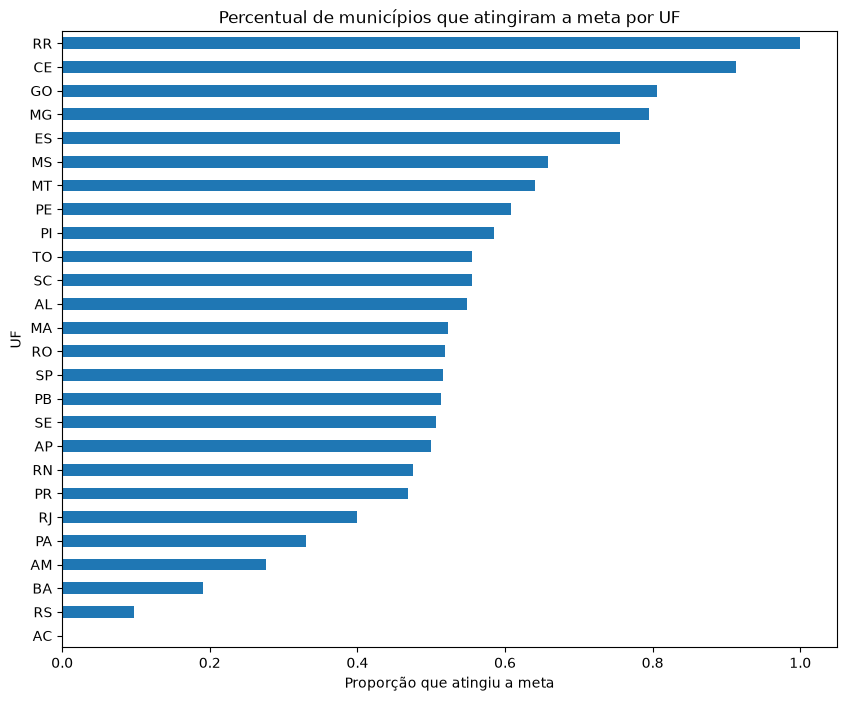

In [11]:
(
    df.groupby("UF")["target_atingiu_meta_2024"]
    .mean()
    .sort_values()
    .plot(
        kind="barh",
        figsize=(10, 8)
    )
)

plt.xlabel("Proporção que atingiu a meta")
plt.ylabel("UF")
plt.title("Percentual de municípios que atingiram a meta por UF")

plt.show()

In [12]:
df.groupby("Capital").agg(
    municipios=("id_municipio", "count"),
    taxa_2023=(
        "taxa_alfabetizacao_2023",
        "mean"
    ),
    meta_2024=(
        "meta_alfabetizacao_2024",
        "mean"
    ),
    gap=(
        "gap_meta_2024",
        "mean"
    ),
    atingiu_meta=(
        "target_atingiu_meta_2024",
        "mean"
    )
)

,municipios,taxa_2023,meta_2024,gap,atingiu_meta
Capital,,,,,
Falso,5211,60.510401,62.172654,1.662253,0.533103
Verdadeiro,21,52.595238,56.963333,4.368095,0.476190


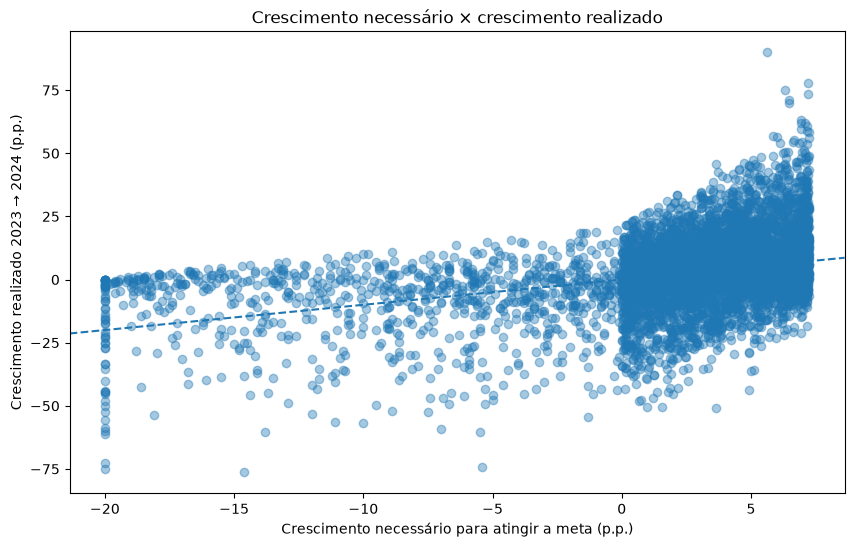

In [15]:
plt.figure(figsize=(10, 6))


df["crescimento_realizado_2024"] = (
    df["taxa_alfabetizacao_2024"]
    - df["taxa_alfabetizacao_2023"]
)



plt.scatter(
    df["gap_meta_2024"],
    df["crescimento_realizado_2024"],
    alpha=0.4
)

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.xlabel("Crescimento necessário para atingir a meta (p.p.)")
plt.ylabel("Crescimento realizado 2023 → 2024 (p.p.)")
plt.title(
    "Crescimento necessário × crescimento realizado"
)

plt.show()

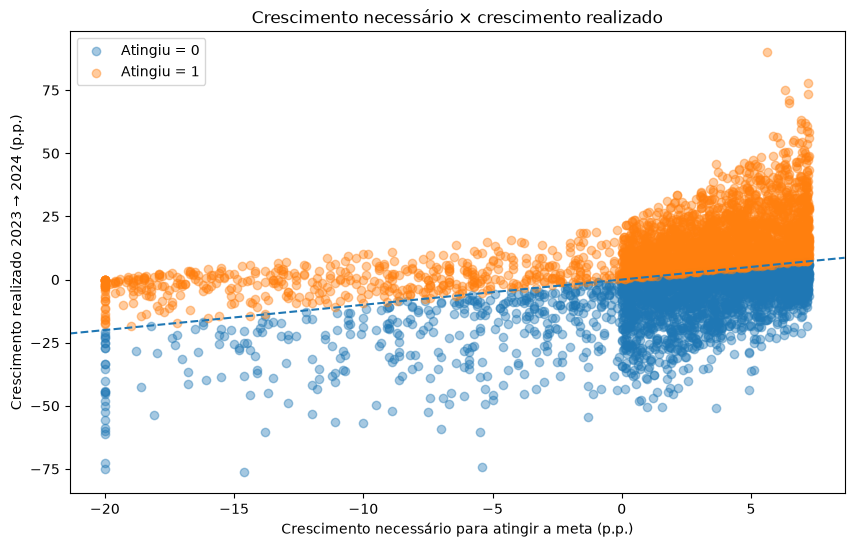

In [16]:
plt.figure(figsize=(10, 6))

for target in [0, 1]:

    dados = df[
        df["target_atingiu_meta_2024"] == target
    ]

    plt.scatter(
        dados["gap_meta_2024"],
        dados["crescimento_realizado_2024"],
        alpha=0.4,
        label=f"Atingiu = {target}"
    )

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.xlabel(
    "Crescimento necessário para atingir a meta (p.p.)"
)

plt.ylabel(
    "Crescimento realizado 2023 → 2024 (p.p.)"
)

plt.title(
    "Crescimento necessário × crescimento realizado"
)

plt.legend()

plt.show()